# Spam Message Classifier

**Goal:** Train a text classification model to detect **spam vs genuine (ham)** messages using a public SMS dataset, then evaluate it using **accuracy, precision, and recall**.

**Pipeline (this is exactly what the CRISP-DM / classic ML workflow looks like):**
1. Import dependencies
2. Load the dataset
3. Summarize the dataset
4. Peek at the data
5. Visualize the data
6. Clean & prepare text (preprocessing + train/test split + vectorization)
7. Train the algorithm(s)
8. Evaluate the algorithm (accuracy, precision, recall, confusion matrix)
9. Make predictions on new messages
10. Save the model

> Note: You asked about the Iris dataset too — Iris is for numeric flower measurements (not text), so it isn't suitable for spam detection. Instead we use the **SMS Spam Collection dataset**, a well-known public dataset of ~5,572 real text messages labeled `spam` or `ham` (genuine).

## Step 1: Import Dependencies

If any of these are not installed, run this in a notebook cell first:
```
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import joblib

sns.set(style="whitegrid")
%matplotlib inline

## Step 2: Load the Dataset

We use the classic **SMS Spam Collection** dataset (UCI Machine Learning Repository), which is publicly hosted and widely used for exactly this task. It has two columns: `label` (`spam`/`ham`) and `message` (the raw text).

This loads it directly from a public URL, so you need an internet connection when you run this cell.

In [2]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(url, header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**If the URL above is ever unreachable**, you can instead download the original dataset manually:
1. Go to https://archive.ics.uci.edu/dataset/228/sms+spam+collection
2. Download `smsspamcollection.zip`, extract `SMSSpamCollection`
3. Load it locally:
```python
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
```
Or use the equivalent Kaggle version: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset (columns there are named `v1`/`v2` — rename them to `label`/`message`).

## Step 3: Summarize the Dataset

In [3]:
# Shape: rows x columns
print("Shape:", df.shape)

# Data types and non-null counts
df.info()

# Class balance
print("\nClass distribution:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [4]:
# Check for missing/duplicate values
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after dropping duplicates: (5169, 2)


## Step 4: Peek at the Data

In [5]:
# First 10 rows
df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [6]:
# A random sample of spam and ham messages
print("--- Sample SPAM messages ---")
for msg in df[df['label'] == 'spam']['message'].sample(3, random_state=1):
    print("-", msg)

print("\n--- Sample HAM (genuine) messages ---")
for msg in df[df['label'] == 'ham']['message'].sample(3, random_state=1):
    print("-", msg)

--- Sample SPAM messages ---
- Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntwk chg £1.50
- Do you want a New Nokia 3510i Colour Phone Delivered Tomorrow? With 200 FREE minutes to any mobile + 100 FREE text + FREE camcorder Reply or Call 08000930705
- You have WON a guaranteed £1000 cash or a £2000 prize. To claim yr prize call our customer service representative on 08714712412 between 10am-7pm Cost 10p

--- Sample HAM (genuine) messages ---
- Am also doing in cbe only. But have to pay.
- Babe! I fucking love you too !! You know? Fuck it was so good to hear your voice. I so need that. I crave it. I can't get enough. I adore you, Ahmad *kisses*
- TELL HER I SAID EAT SHIT.


## Step 5: Visualize the Data

/tmp/ipykernel_72453/603393379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


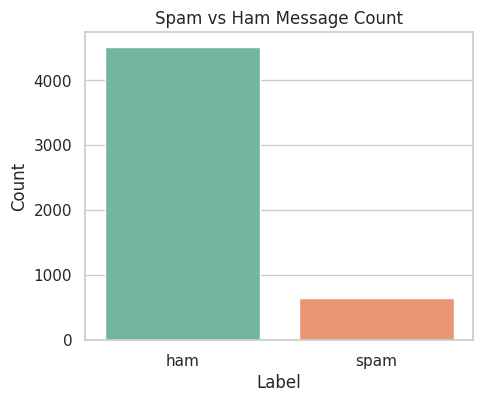

In [7]:
# Class balance bar chart
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Spam vs Ham Message Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

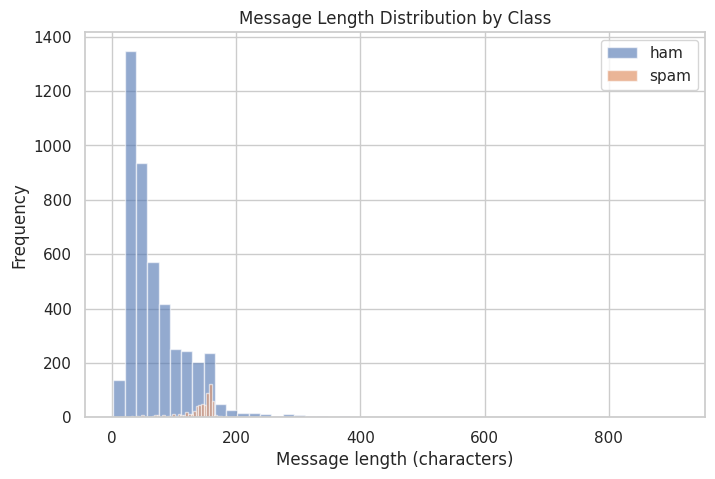

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


In [8]:
# Message length distribution by class
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
df[df['label']=='ham']['message_length'].plot(kind='hist', bins=50, alpha=0.6, label='ham')
df[df['label']=='spam']['message_length'].plot(kind='hist', bins=50, alpha=0.6, label='spam')
plt.legend()
plt.title('Message Length Distribution by Class')
plt.xlabel('Message length (characters)')
plt.show()

df.groupby('label')['message_length'].describe()

ValueError: Only supported for TrueType fonts

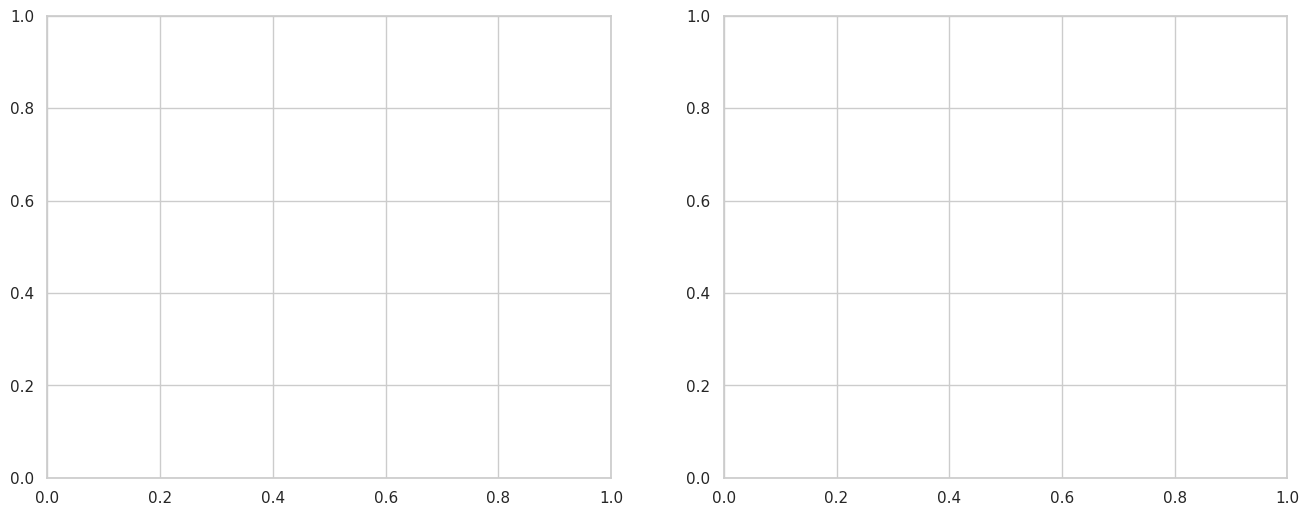

In [9]:
# Optional: word clouds (requires `pip install wordcloud`)
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label']=='spam']['message'])
ham_text = ' '.join(df[df['label']=='ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(WordCloud(width=600, height=400, background_color='white').generate(spam_text))
axes[0].set_title('Most common words in SPAM')
axes[0].axis('off')

axes[1].imshow(WordCloud(width=600, height=400, background_color='white').generate(ham_text))
axes[1].set_title('Most common words in HAM')
axes[1].axis('off')
plt.show()

## Step 6: Prepare the Data

Text has to be converted into numbers before a model can learn from it. Steps:
1. Encode labels (`ham` → 0, `spam` → 1)
2. Split into train/test sets
3. Vectorize text with **TF-IDF** (turns each message into a vector of word-importance scores)

In [ ]:
# Encode labels: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']

# 80% train, 20% test, stratified so both sets keep the same spam/ham ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

In [ ]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True, max_df=0.95, min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)   # fit ONLY on training data
X_test_vec = vectorizer.transform(X_test)          # transform test data using the same vocabulary

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train_vec.shape)

## Step 7: Train the Algorithm(s)

We'll train **Multinomial Naive Bayes** (the classic, very effective baseline for text classification) and compare it against **Logistic Regression** and a **Linear SVM**, so you can see how to evaluate multiple algorithms — a common assignment requirement.

In [ ]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df

## Step 8: Evaluate the Algorithm

- **Accuracy** — overall % of messages correctly classified.
- **Precision** — of the messages predicted as spam, how many were actually spam (matters if you don't want genuine messages wrongly blocked).
- **Recall** — of all actual spam messages, how many did the model catch (matters if you don't want spam slipping through).

We pick the best-performing model (by F1, which balances precision and recall) and inspect it more closely.

In [10]:
best_model_name = results_df['f1'].idxmax()
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

y_pred = best_model.predict(X_test_vec)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

NameError: name 'results_df' is not defined

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

In [ ]:
# Bar chart comparing all models on accuracy/precision/recall
results_df[['accuracy', 'precision', 'recall']].plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

## Step 9: Make Predictions on New Messages

In [ ]:
def predict_message(message, model=best_model, vec=vectorizer):
    vec_msg = vec.transform([message])
    pred = model.predict(vec_msg)[0]
    return 'SPAM' if pred == 1 else 'HAM (genuine)'

sample_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "URGENT: Your account has been suspended. Verify your details immediately to avoid closure.",
    "Can you send me the notes from today's class?"
]

for msg in sample_messages:
    print(f"[{predict_message(msg)}] {msg}")

## Step 10: Save the Model

Save both the trained model and the vectorizer so they can be reloaded later without retraining.

In [ ]:
joblib.dump(best_model, 'spam_classifier_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Saved: spam_classifier_model.pkl, tfidf_vectorizer.pkl")

# To reload later:
# model = joblib.load('spam_classifier_model.pkl')
# vectorizer = joblib.load('tfidf_vectorizer.pkl')

## Conclusion

- Loaded a public SMS dataset of ~5,500 labeled messages.
- Explored class balance and message-length patterns.
- Converted text to numeric features using TF-IDF.
- Trained and compared three algorithms (Naive Bayes, Logistic Regression, Linear SVM).
- Evaluated with accuracy, precision, and recall, and visualized results with a confusion matrix.
- Used the trained model to classify brand-new messages.

Naive Bayes typically performs very well on this dataset (often 97%+ accuracy) and is the traditional go-to baseline for spam filtering.